# 📊 Notebook 1 — Keşifsel Veri Analizi (EDA) ve Metin Ön İşleme
## CV – İlan Eşleşmesi | Proje [50]

**Ders:** Doğal Dil İşleme | **Öğretim Elemanı:** Dr. Rabia Yaşa Koştaş

### İçerik:
1. Kurulum ve veri yükleme
2. Ham metin incelemesi
3. Metin ön işleme — 6 adım (tek hücrede)
4. Token frekans analizi
5. TF-IDF matrisi görselleştirme
6. Kosinüs benzerliği — elle hesaplama


## 1. Kurulum ve Veri Yükleme

In [ ]:
import os, re, sys, string, unicodedata, warnings
warnings.filterwarnings('ignore')
from collections import Counter

import os
_current = os.path.abspath('')
PROJECT_DIR = _current
while _current != os.path.dirname(_current):
    if os.path.exists(os.path.join(_current, 'app.py')):
        PROJECT_DIR = _current
        break
    _current = os.path.dirname(_current)

sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)
PLOTS = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(PLOTS, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

plt.style.use('seaborn-v0_8-whitegrid')
stop_en = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Veri yükle
df_raw = pd.read_csv(os.path.join(PROJECT_DIR, 'data', 'cv_jobs_raw.csv'))
df_mod = pd.read_csv(os.path.join(PROJECT_DIR, 'data', 'cv_jobs_dataset.csv'))

df_raw['word_count'] = df_raw['content'].apply(lambda x: len(str(x).split()))
df_raw['char_count'] = df_raw['content'].apply(lambda x: len(str(x)))

print(f"✅ Kurulum tamamlandı!")
print(f"   Proje dizini : {PROJECT_DIR}")
print(f"   Plots dizini : {PLOTS}")
print(f"   Toplam belge : {len(df_raw)}")
print(f"   CV sayısı    : {len(df_raw[df_raw['type']=='cv'])}")
print(f"   İş ilanı     : {len(df_raw[df_raw['type']=='job_posting'])}")
print(f"   Kategoriler  : {list(df_raw['category'].unique())}")


✅ Kurulum tamamlandı!
   Proje dizini : c:\Users\andya\Documents\BİLGİSAYAR PROGRAMCILIĞI\2º Sınıf\2º Dönem\6. Doğal Dil işleme\Proje\cv_matching
   Plots dizini : c:\Users\andya\Documents\BİLGİSAYAR PROGRAMCILIĞI\2º Sınıf\2º Dönem\6. Doğal Dil işleme\Proje\cv_matching\plots
   Toplam belge : 280
   CV sayısı    : 250
   İş ilanı     : 30
   Kategoriler  : ['Data Science', 'Software Engineering', 'Marketing', 'Finance', 'Human Resources', 'Healthcare', 'Education', 'Sales', 'Project Management', 'Cybersecurity']


## 2. Ham Metin İncelemesi

In [2]:
for kat in df_raw['category'].unique()[:3]:
    ornek = df_raw[df_raw['category']==kat].iloc[0]
    print(f"{'─'*60}")
    print(f"Kategori: {kat} | ID: {ornek['document_id']}")
    print(ornek['content'][:250])
    print()


────────────────────────────────────────────────────────────
Kategori: Data Science | ID: cv_001
Isabella Wilson principal professional with 18 years experience in data science field.

SKILLS AND EXPERTISE:
supervised learning unsupervised learning reinforcement learning convolutional neural networks recurrent neural networks transformers bert g

────────────────────────────────────────────────────────────
Kategori: Software Engineering | ID: cv_002
Brittany Johnson senior professional with 7 years experience in software engineering field.

SKILLS AND EXPERTISE:
java python javascript typescript react angular vue nodejs express django flask spring boot microservices rest api graphql docker kuber

────────────────────────────────────────────────────────────
Kategori: Marketing | ID: cv_003
Omar Brown senior professional with 3 years experience in marketing field.

SKILLS AND EXPERTISE:
market research competitive analysis customer segmentation buyer persona campaign management marketing

## 3. Veri Dağılımı

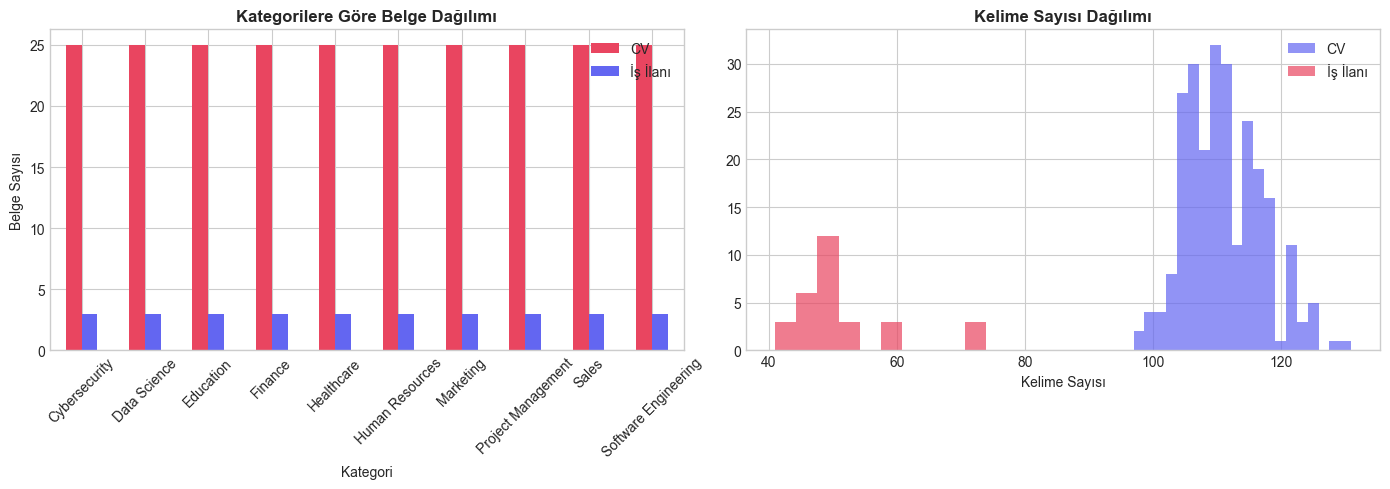

✅ Grafik kaydedildi.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_raw.groupby(['category','type']).size().unstack(fill_value=0)
cat_counts.plot(kind='bar', ax=axes[0], color=['#e94560','#6366f1'])
axes[0].set_title('Kategorilere Göre Belge Dağılımı', fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Belge Sayısı')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['CV','İş İlanı'])

axes[1].hist(df_raw[df_raw['type']=='cv']['word_count'], bins=20,
             color='#6366f1', alpha=0.7, label='CV')
axes[1].hist(df_raw[df_raw['type']=='job_posting']['word_count'], bins=10,
             color='#e94560', alpha=0.7, label='İş İlanı')
axes[1].set_title('Kelime Sayısı Dağılımı', fontweight='bold')
axes[1].set_xlabel('Kelime Sayısı')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS, '01_veri_dagilimi.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi.")


## 4. Metin Ön İşleme — 6 Adım

Her adımın metni nasıl değiştirdiğini görmek için örnek bir CV üzerinde uyguluyoruz.


In [5]:
# Örnek metin: ilk Data Science CV'si
ornek_metin = df_raw[df_raw['category']=='Data Science'].iloc[0]['content']

print("=" * 60)
print("ADIM 0 — Ham Metin:")
print(ornek_metin[:200])
print(f"Kelime sayısı: {len(ornek_metin.split())}")

# Adım 1: Unicode normalizasyonu
adim1 = unicodedata.normalize('NFKD', ornek_metin)
print("\n" + "=" * 60)
print("ADIM 1 — Unicode Normalizasyonu:")
print(adim1[:200])

# Adım 2: Küçük harfe çevirme
adim2 = adim1.lower()
print("\n" + "=" * 60)
print("ADIM 2 — Küçük Harfe Çevirme:")
print(adim2[:200])

# Adım 3: URL ve e-posta kaldırma
adim3 = re.sub(r'http\S+|www\.\S+', ' ', adim2)
adim3 = re.sub(r'\S+@\S+\.\S+', ' ', adim3)
print("\n" + "=" * 60)
print("ADIM 3 — URL ve E-posta Kaldırma:")
print(adim3[:200])

# Adım 4: Sayıları kaldırma
adim4 = re.sub(r'\b\d+\b', ' ', adim3)
print("\n" + "=" * 60)
print("ADIM 4 — Sayı Kaldırma:")
print(adim4[:200])

# Adım 5: Noktalama kaldırma
adim5 = adim4.translate(str.maketrans(string.punctuation, ' '*len(string.punctuation)))
adim5 = re.sub(r'\s+', ' ', adim5).strip()
print("\n" + "=" * 60)
print("ADIM 5 — Noktalama Kaldırma:")
print(adim5[:200])

# Adım 6: Stopword eleme
adim6_tokens = [w for w in adim5.split() if w not in stop_en and len(w) > 2]
adim6 = ' '.join(adim6_tokens)
print("\n" + "=" * 60)
print("ADIM 6 — Stopword Eleme (son hali):")
print(adim6[:300])
print(f"\nKalan token sayısı: {len(adim6_tokens)}")


ADIM 0 — Ham Metin:
Isabella Wilson principal professional with 18 years experience in data science field.

SKILLS AND EXPERTISE:
supervised learning unsupervised learning reinforcement learning convolutional neural netw
Kelime sayısı: 115

ADIM 1 — Unicode Normalizasyonu:
Isabella Wilson principal professional with 18 years experience in data science field.

SKILLS AND EXPERTISE:
supervised learning unsupervised learning reinforcement learning convolutional neural netw

ADIM 2 — Küçük Harfe Çevirme:
isabella wilson principal professional with 18 years experience in data science field.

skills and expertise:
supervised learning unsupervised learning reinforcement learning convolutional neural netw

ADIM 3 — URL ve E-posta Kaldırma:
isabella wilson principal professional with 18 years experience in data science field.

skills and expertise:
supervised learning unsupervised learning reinforcement learning convolutional neural netw

ADIM 4 — Sayı Kaldırma:
isabella wilson principal profes

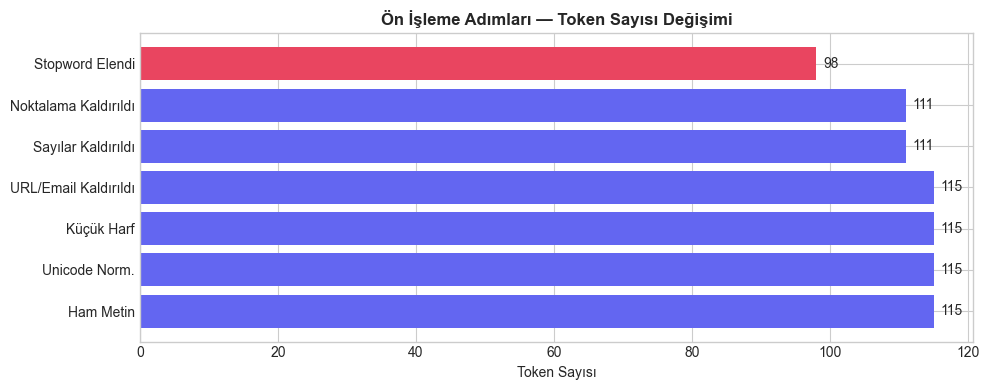

✅ Grafik kaydedildi.


In [6]:
adimlar = {
    'Ham Metin'           : len(ornek_metin.split()),
    'Unicode Norm.'       : len(adim1.split()),
    'Küçük Harf'          : len(adim2.split()),
    'URL/Email Kaldırıldı': len(adim3.split()),
    'Sayılar Kaldırıldı'  : len(adim4.split()),
    'Noktalama Kaldırıldı': len(adim5.split()),
    'Stopword Elendi'     : len(adim6_tokens),
}

fig, ax = plt.subplots(figsize=(10, 4))
renkler = ['#e94560' if i==len(adimlar)-1 else '#6366f1' for i in range(len(adimlar))]
bars = ax.barh(list(adimlar.keys()), list(adimlar.values()), color=renkler)
ax.set_title('Ön İşleme Adımları — Token Sayısı Değişimi', fontweight='bold')
ax.set_xlabel('Token Sayısı')
for bar, val in zip(bars, adimlar.values()):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, '02_onisleme_adimlar.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi.")


## 5. Token Frekans Analizi

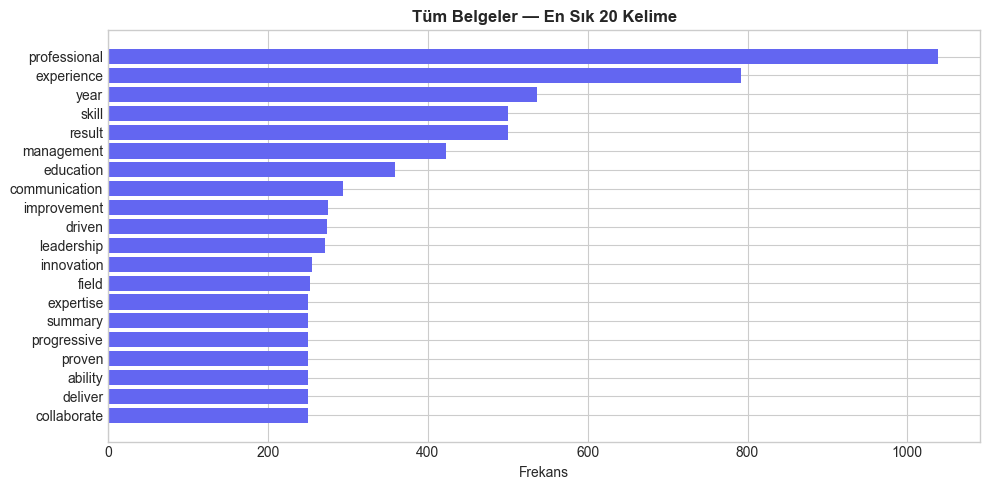

✅ Grafik kaydedildi.


In [7]:
def temizle(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(t) for t in tokens
                     if t.isalpha() and t not in stop_en and len(t) > 2])

df_raw['temiz'] = df_raw['content'].apply(temizle)

tum = ' '.join(df_raw['temiz']).split()
frekans = Counter(tum).most_common(20)
kelimeler, sayilar = zip(*frekans)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(kelimeler), list(sayilar), color='#6366f1')
ax.set_title('Tüm Belgeler — En Sık 20 Kelime', fontweight='bold')
ax.set_xlabel('Frekans')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, '03_token_frekanslari.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi.")


## 6. TF-IDF Matrisi Görselleştirme

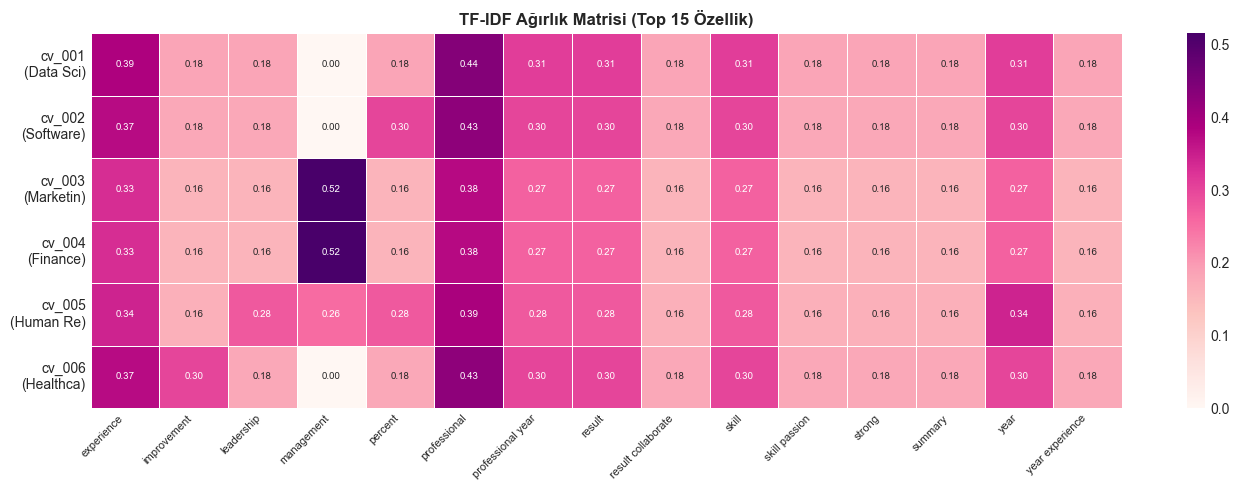

✅ Grafik kaydedildi.


In [8]:
ornekler = df_raw.head(6)
metinler = [df_raw[df_raw['document_id']==r['document_id']]['temiz'].values[0]
            for _, r in ornekler.iterrows()]
etiketler = [f"{r['document_id']}\n({r['category'][:8]})" for _, r in ornekler.iterrows()]

vec = TfidfVectorizer(ngram_range=(1,2), max_features=15, sublinear_tf=True)
matrix = vec.fit_transform(metinler).toarray()
features = vec.get_feature_names_out()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(matrix, xticklabels=features, yticklabels=etiketler,
            cmap='RdPu', annot=True, fmt='.2f', linewidths=0.5,
            linecolor='white', ax=ax, annot_kws={'size':7})
ax.set_title('TF-IDF Ağırlık Matrisi (Top 15 Özellik)', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, '04_tfidf_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi.")


## 7. Kosinüs Benzerliği — Elle Hesaplama ve Doğrulama

In [9]:
def cosine_manuel(A, B):
    dot   = np.dot(A, B)
    norm_a = np.linalg.norm(A)
    norm_b = np.linalg.norm(B)
    if norm_a == 0 or norm_b == 0: return 0.0
    return float(dot / (norm_a * norm_b))

is_ilani  = df_raw[df_raw['type']=='job_posting'].iloc[0]
cv_ler    = df_raw[df_raw['type']=='cv'].head(5)

tum       = pd.concat([is_ilani.to_frame().T, cv_ler])
tum_temiz = [df_raw[df_raw['document_id']==r['document_id']]['temiz'].values[0]
             for _, r in tum.iterrows()]

vec2   = TfidfVectorizer(ngram_range=(1,2), max_features=5000, sublinear_tf=True)
m2     = vec2.fit_transform(tum_temiz).toarray()
is_vec = m2[0]
cv_vecs = m2[1:]

print("Kosinüs Benzerlik Skorları (Manuel vs Sklearn):")
print("─" * 52)
sonuclar = []
for i, (_, row) in enumerate(cv_ler.iterrows()):
    manuel  = cosine_manuel(is_vec, cv_vecs[i])
    sklearn_ = cosine_similarity([is_vec],[cv_vecs[i]])[0][0]
    print(f"  {row['document_id']:<12} Manuel:{manuel:.4f}  Sklearn:{sklearn_:.4f}")
    sonuclar.append({'belge': row['document_id'], 'skor': manuel})
print("\n✅ Manuel = Sklearn — Formül doğrulandı!")


Kosinüs Benzerlik Skorları (Manuel vs Sklearn):
────────────────────────────────────────────────────
  cv_001       Manuel:0.1070  Sklearn:0.1070
  cv_002       Manuel:0.0353  Sklearn:0.0353
  cv_003       Manuel:0.0148  Sklearn:0.0148
  cv_004       Manuel:0.0151  Sklearn:0.0151
  cv_005       Manuel:0.0277  Sklearn:0.0277

✅ Manuel = Sklearn — Formül doğrulandı!


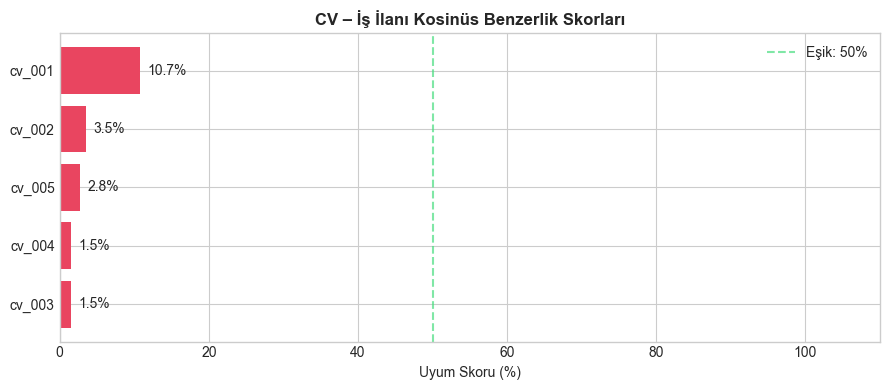

✅ Grafik kaydedildi.


In [10]:
df_son = pd.DataFrame(sonuclar).sort_values('skor', ascending=True)
renkler = ['#4ade80' if s>=0.6 else '#f59e0b' if s>=0.35 else '#e94560'
           for s in df_son['skor']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_son['belge'], df_son['skor']*100, color=renkler)
ax.axvline(x=50, color='#4ade80', linestyle='--', alpha=0.7, label='Eşik: 50%')
ax.set_xlabel('Uyum Skoru (%)')
ax.set_title('CV – İş İlanı Kosinüs Benzerlik Skorları', fontweight='bold')
ax.set_xlim(0, 110)
for bar, val in zip(bars, df_son['skor']):
    ax.text(val*100+1, bar.get_y()+bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, '05_cosine_skorlar.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi.")


## 8. Özet

Bu notebook'ta:
- ✅ 280 belgeden oluşan CV–İlan veri setini yükledik
- ✅ 6 adımlı metin ön işleme pipeline'ını adım adım uyguladık
- ✅ Token frekans analizi yaptık
- ✅ TF-IDF matrisini ısı haritası ile görselleştirdik
- ✅ Kosinüs benzerliğini hem elle hem Scikit-learn ile hesaplayarak doğruladık

**Sonraki adım:** `02_model_karsilastirma.ipynb` — TF-IDF vs Word2Vec karşılaştırması
